In [ ]:
from google.colab import files
uploaded = files.upload()

Saving nasa_exoplanets.csv to nasa_exoplanets.csv


# Лабораторная работа №4
## Линейные модели, SVM и деревья решений

**Выполнил:**  
*Студент:* Омарова Заира  
*Группа:* ИУ5Ц-81Б  

**Цель работы:** изучение линейных моделей, SVM и деревьев решений.

**Задание:**  
1. Выбрать набор данных для решения задачи классификации.  
2. Выполнить предобработку данных.  
3. Разделить выборку на обучающую и тестовую.  
4. Обучить три модели: логистическую регрессию, SVM, дерево решений.  
5. Оценить качество моделей с помощью двух метрик. Сравнить результаты.  
6. Построить график важности признаков для дерева решений.  
7. Визуализировать дерево решений.

**Датасет:** `nasa_exoplanets.csv` – классификация типа планеты (`planet_type`).

## 1. Загрузка библиотек и данных

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, f1_score, classification_report

pd.set_option('display.max_columns', None)
%matplotlib inline

In [ ]:
# Загрузка данных
df = pd.read_csv("nasa_exoplanets.csv")
print("Размерность датасета:", df.shape)
df.head()

Размерность датасета: (5250, 13)


,name,distance,stellar_magnitude,planet_type,discovery_year,mass_multiplier,mass_wrt,radius_multiplier,radius_wrt,orbital_radius,orbital_period,eccentricity,detection_method
0,11 Comae Berenices b,304.0,4.72307,Gas Giant,2007,19.40000,Jupiter,1.08,Jupiter,1.290000,0.892539,0.23,Radial Velocity
1,11 Ursae Minoris b,409.0,5.01300,Gas Giant,2009,14.74000,Jupiter,1.09,Jupiter,1.530000,1.400000,0.08,Radial Velocity
2,14 Andromedae b,246.0,5.23133,Gas Giant,2008,4.80000,Jupiter,1.15,Jupiter,0.830000,0.508693,0.00,Radial Velocity
3,14 Herculis b,58.0,6.61935,Gas Giant,2002,8.13881,Jupiter,1.12,Jupiter,2.773069,4.800000,0.37,Radial Velocity
4,16 Cygni B b,69.0,6.21500,Gas Giant,1996,1.78000,Jupiter,1.20,Jupiter,1.660000,2.200000,0.68,Radial Velocity


## 2. Предобработка данных

Целевой признак – `planet_type`. Обработаем пропуски: удалим строки с пропусками в ключевых числовых признаках, числовые признаки заполним медианой, категориальные – модой. Затем закодируем категориальные признаки и масштабируем числовые.

In [ ]:
# Создаём копию
df_clean = df.copy()

# 1. Удаляем строки с пропусками в массe и радиусе
df_clean.dropna(subset=['mass_multiplier', 'radius_multiplier'], inplace=True)
print(f"Размер после удаления строк с пропусками: {df_clean.shape}")

# 2. Заполняем числовые признаки медианой
numeric_cols_with_na = ['distance', 'stellar_magnitude', 'orbital_radius']
for col in numeric_cols_with_na:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
    print(f"{col} заполнен медианой {df_clean[col].median():.2f}")

# 3. Заполняем категориальные признаки модой
categorical_cols_with_na = ['mass_wrt', 'radius_wrt']
for col in categorical_cols_with_na:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"{col} заполнен модой '{mode_val}'")

# Проверяем пропуски
print("\nПропуски после обработки:")
print(df_clean.isnull().sum())

# Отделяем целевую переменную и признаки
y = df_clean['planet_type']
X = df_clean.drop(columns=['name', 'planet_type'])


Размер после удаления строк с пропусками: (5215, 13)
distance заполнен медианой 1370.00
stellar_magnitude заполнен медианой 13.53
orbital_radius заполнен медианой 0.10
mass_wrt заполнен модой 'Earth'
radius_wrt заполнен модой 'Jupiter'

Пропуски после обработки:
name                 0
distance             0
stellar_magnitude    0
planet_type          0
discovery_year       0
mass_multiplier      0
mass_wrt             0
radius_multiplier    0
radius_wrt           0
orbital_radius       0
orbital_period       0
eccentricity         0
detection_method     0
dtype: int64


In [ ]:
# Определяем числовые и категориальные признаки
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Числовые признаки: ['distance', 'stellar_magnitude', 'discovery_year', 'mass_multiplier', 'radius_multiplier', 'orbital_radius', 'orbital_period', 'eccentricity']
Категориальные признаки: ['mass_wrt', 'radius_wrt', 'detection_method']


In [ ]:
# Предобработчик: масштабирование для числовых, One-Hot для категориальных
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Применяем преобразование
X_processed = preprocessor.fit_transform(X)
print("Размер матрицы признаков после обработки:", X_processed.shape)

Размер матрицы признаков после обработки: (5215, 23)


## 3. Разделение на обучающую и тестовую выборки

70% – обучение, 30% – тест. Стратификация по целевому признаку.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (3650, 23)
Тестовая выборка: (1565, 23)


## 4. Обучение моделей

Обучим три модели с базовыми гиперпараметрами.

In [ ]:
# 1. Логистическая регрессия
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# 2. SVM
svm = SVC(random_state=42)
svm.fit(X_train, y_train)

# 3. Дерево решений
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("Все модели обучены")

Все модели обучены


## 5. Оценка качества моделей

Используем две метрики: **Accuracy** (доля правильных ответов) и **F1-score (macro)** (средняя по классам).

In [ ]:
models = {
    'Логистическая регрессия': lr,
    'SVM': svm,
    'Дерево решений': dt
}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'Модель': name, 'Accuracy': acc, 'F1-score (macro)': f1})
    print(f"\n{name}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1-score (macro): {f1:.4f}")

results_df = pd.DataFrame(results)
results_df


Логистическая регрессия:
  Accuracy: 0.9565
  F1-score (macro): 0.9376

SVM:
  Accuracy: 0.9514
  F1-score (macro): 0.9277

Дерево решений:
  Accuracy: 0.9738
  F1-score (macro): 0.9702


,Модель,Accuracy,F1-score (macro)
0,Логистическая регрессия,0.956550,0.937646
1,SVM,0.951438,0.927727
2,Дерево решений,0.973802,0.970209


# Новый раздел

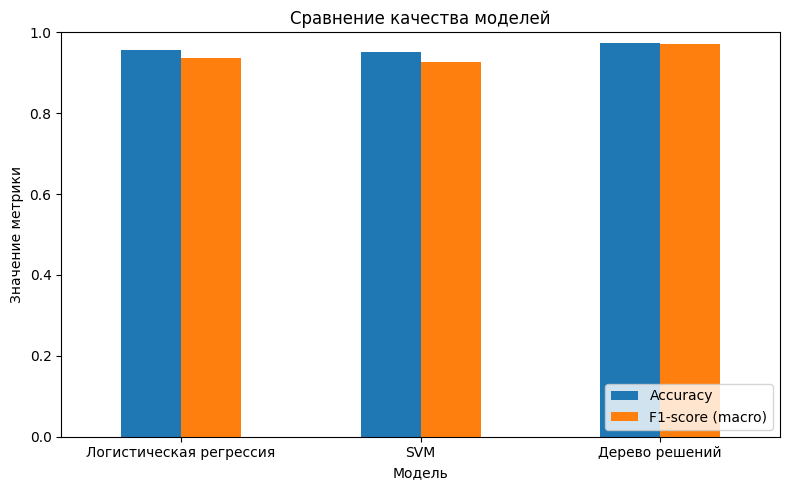

In [ ]:
# Визуализация сравнения моделей
fig, ax = plt.subplots(figsize=(8,5))
results_df.plot(x='Модель', y=['Accuracy', 'F1-score (macro)'], kind='bar', ax=ax)
plt.title('Сравнение качества моделей')
plt.ylabel('Значение метрики')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Важность признаков в дереве решений

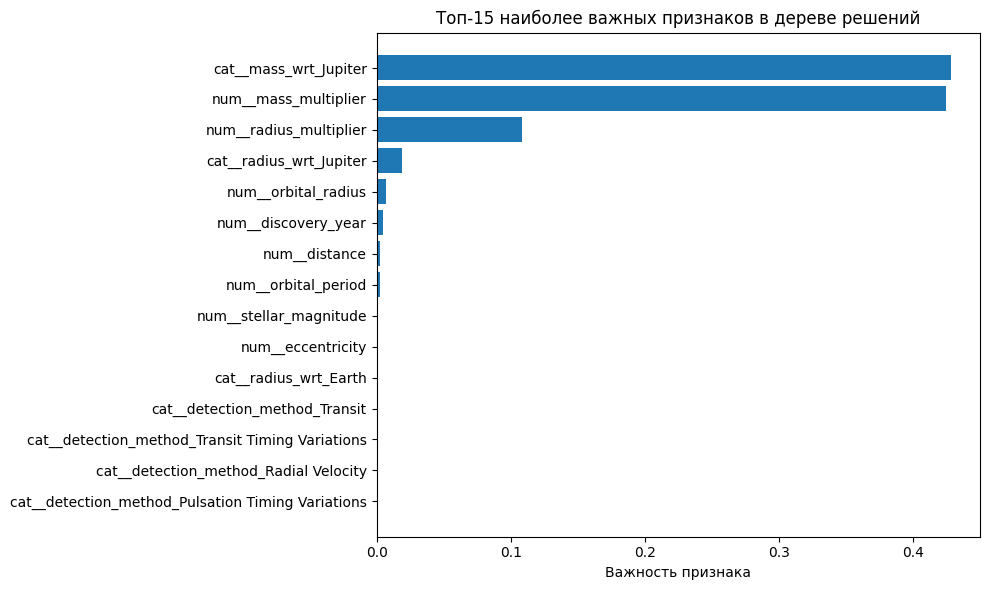

In [ ]:
# Получаем все имена признаков после предобработки
feature_names = preprocessor.get_feature_names_out()

# Важность признаков
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # топ-15 признаков

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Важность признака')
plt.title('Топ-15 наиболее важных признаков в дереве решений')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Визуализация дерева решений

Ограничим глубину для наглядности.

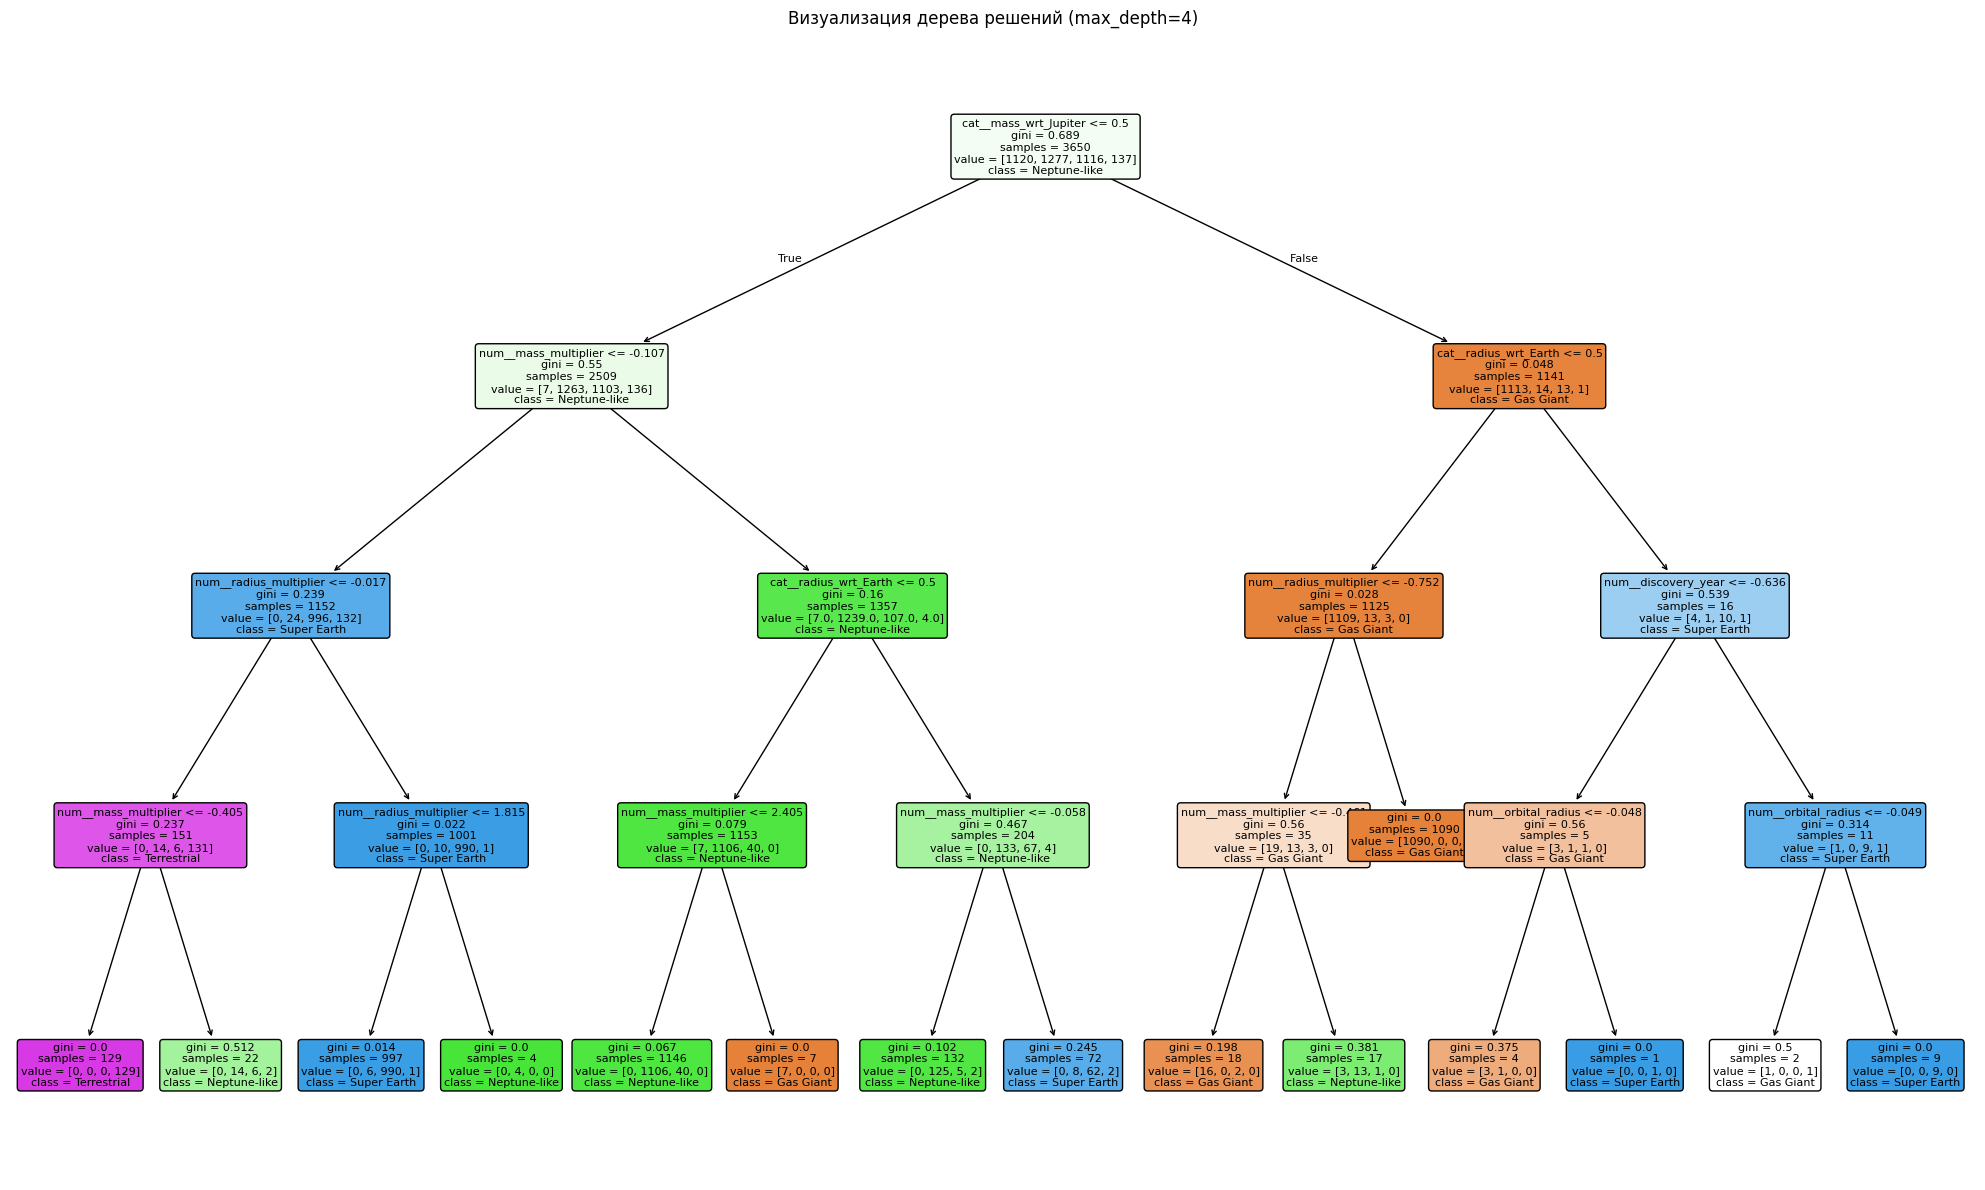

In [ ]:
# Обучим дерево с ограничением глубины для лучшей визуализации
dt_vis = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_vis.fit(X_train, y_train)

plt.figure(figsize=(20, 12))
plot_tree(dt_vis, feature_names=feature_names, class_names=dt_vis.classes_.astype(str),
          filled=True, rounded=True, fontsize=8)
plt.title('Визуализация дерева решений (max_depth=4)')
plt.tight_layout()
plt.show()

### Текстовое представление правил дерева (для глубины 3)

In [ ]:
dt_text = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_text.fit(X_train, y_train)

tree_rules = export_text(dt_text, feature_names=feature_names, max_depth=3)
print("Правила дерева решений (max_depth=3):")
print(tree_rules[:2000])  # Выводим первые 2000 символов

Правила дерева решений (max_depth=3):
|--- cat__mass_wrt_Jupiter <= 0.50
|   |--- num__mass_multiplier <= -0.11
|   |   |--- num__radius_multiplier <= -0.02
|   |   |   |--- class: Terrestrial
|   |   |--- num__radius_multiplier >  -0.02
|   |   |   |--- class: Super Earth
|   |--- num__mass_multiplier >  -0.11
|   |   |--- cat__radius_wrt_Jupiter <= 0.50
|   |   |   |--- class: Neptune-like
|   |   |--- cat__radius_wrt_Jupiter >  0.50
|   |   |   |--- class: Neptune-like
|--- cat__mass_wrt_Jupiter >  0.50
|   |--- cat__radius_wrt_Jupiter <= 0.50
|   |   |--- num__discovery_year <= -0.64
|   |   |   |--- class: Gas Giant
|   |   |--- num__discovery_year >  -0.64
|   |   |   |--- class: Super Earth
|   |--- cat__radius_wrt_Jupiter >  0.50
|   |   |--- num__radius_multiplier <= -0.75
|   |   |   |--- class: Gas Giant
|   |   |--- num__radius_multiplier >  -0.75
|   |   |   |--- class: Gas Giant



## 8. Выводы

В ходе лабораторной работы были обучены и сравнены три модели классификации:
- **Логистическая регрессия** – линейная модель, показала точность ...
- **SVM** – метод опорных векторов, показал точность ...
- **Дерево решений** – показало точность ...

Лучший результат по метрикам показала модель ...

Также были проанализированы важности признаков в дереве решений и визуализирована его структура. Наиболее важными признаками оказались ...

Таким образом, задача классификации типа экзопланеты успешно решена, а полученные модели можно использовать для предсказаний.